Done with imports
<TableColumns names=('Catalogue_Number','xcentroid','ycentroid','RA','DEC','sharpness','roundness1','roundness2','smoothness','flux','eflux','sky','flag','F480M','eF480M')>
<TableColumns names=('Catalogue_Number','xcentroid','ycentroid','RA','DEC','sharpness','roundness1','roundness2','smoothness','flux','eflux','sky','flag','F480M','eF480M')>
<TableColumns names=('Catalogue_Number','xcentroid','ycentroid','RA','DEC','sharpness','roundness1','roundness2','smoothness','flux','eflux','sky','flag','F480M','eF480M')>
<TableColumns names=('Catalogue_Number','xcentroid','ycentroid','RA','DEC','sharpness','roundness1','roundness2','smoothness','flux','eflux','sky','flag','F480M','eF480M')>
<TableColumns names=('Catalogue_Number','xcentroid','ycentroid','RA','DEC','sharpness','roundness1','roundness2','smoothness','flux','eflux','sky','flag','F480M','eF480M')>
<TableColumns names=('Catalogue_Number','xcentroid','ycentroid','RA','DEC','sharpness','roundness1','roundness2','smo

FileNotFoundError: [Errno 2] No such file or directory: '/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151001001_03109_00005_nrcblong_cal_starbug2-bgd.fits'

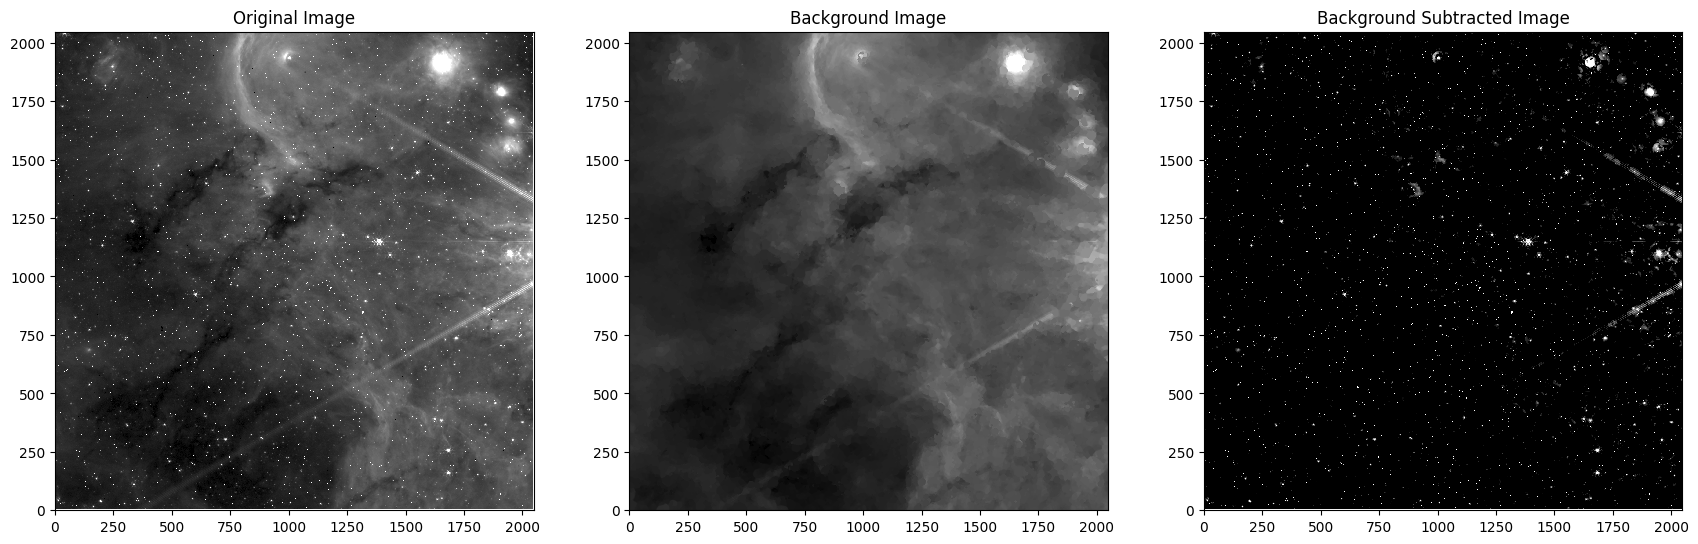

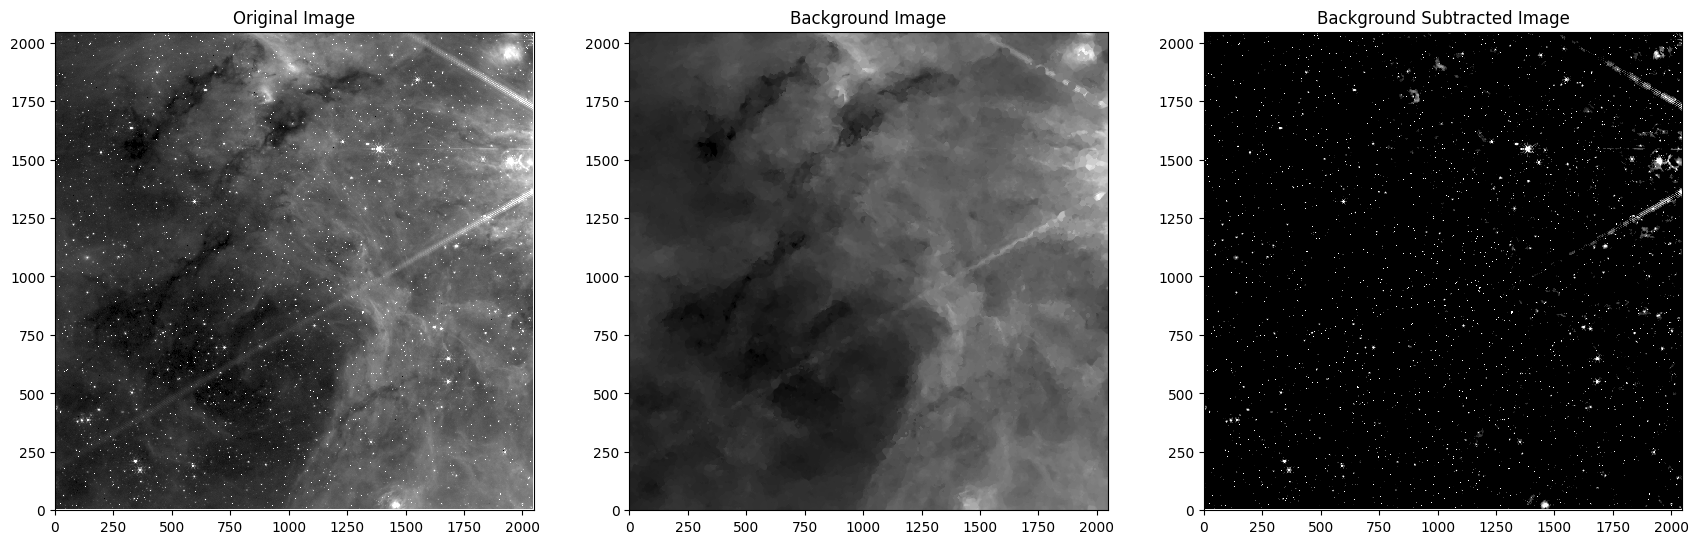

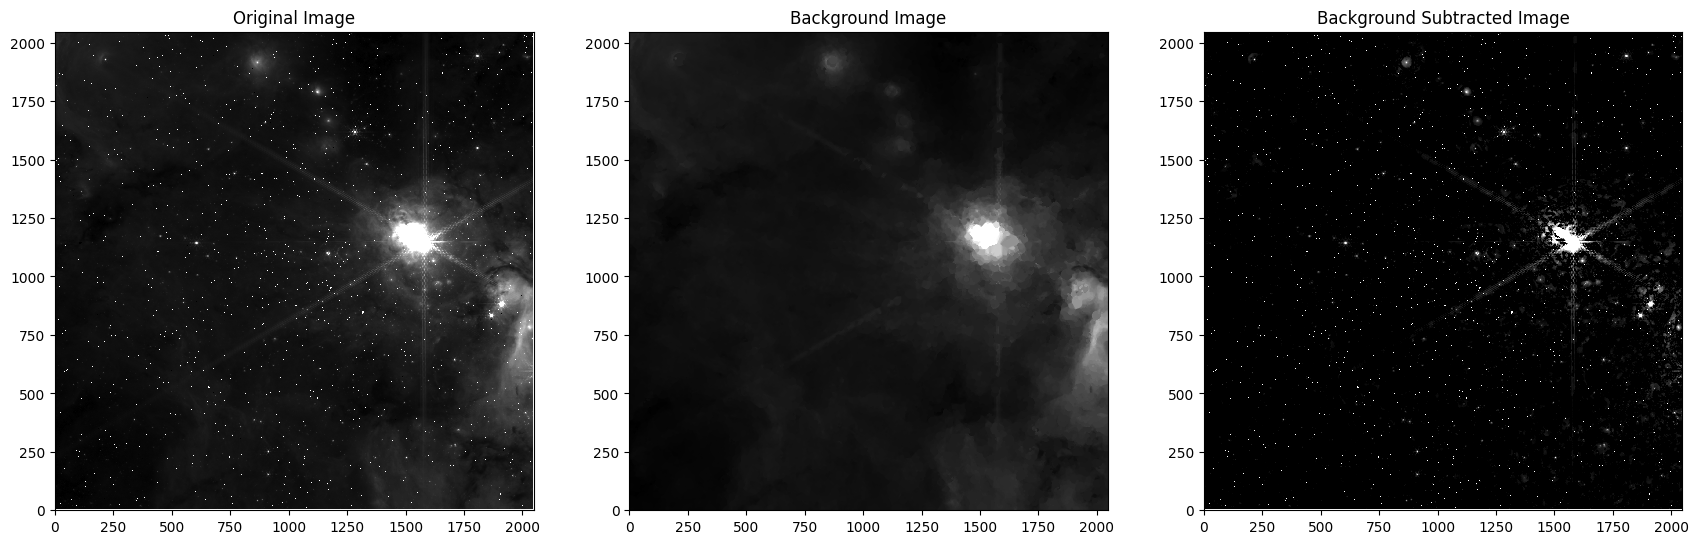

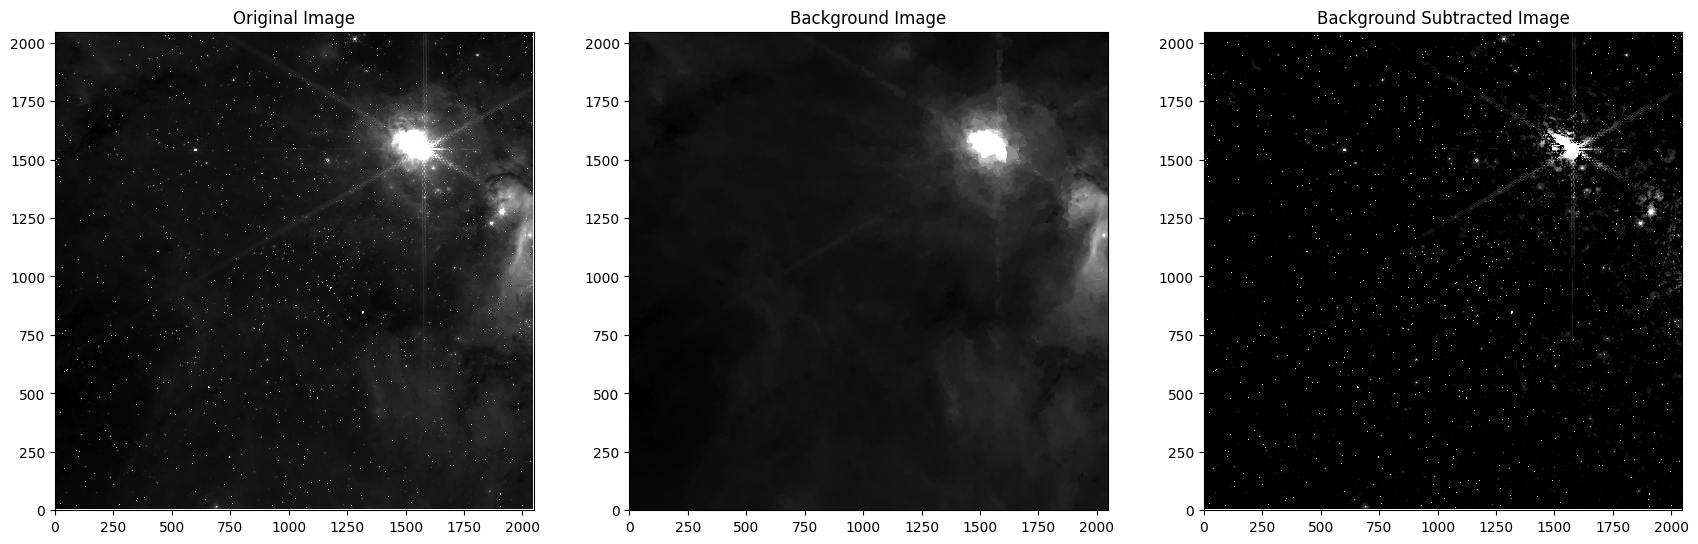

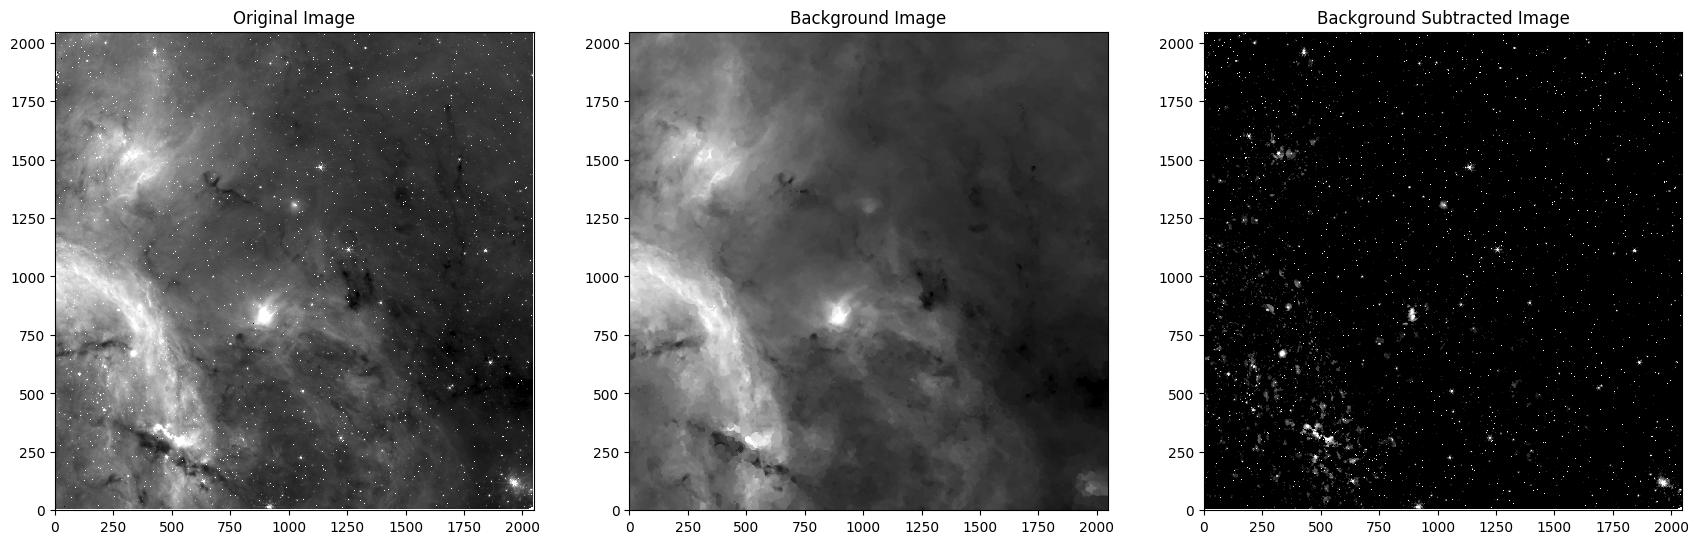

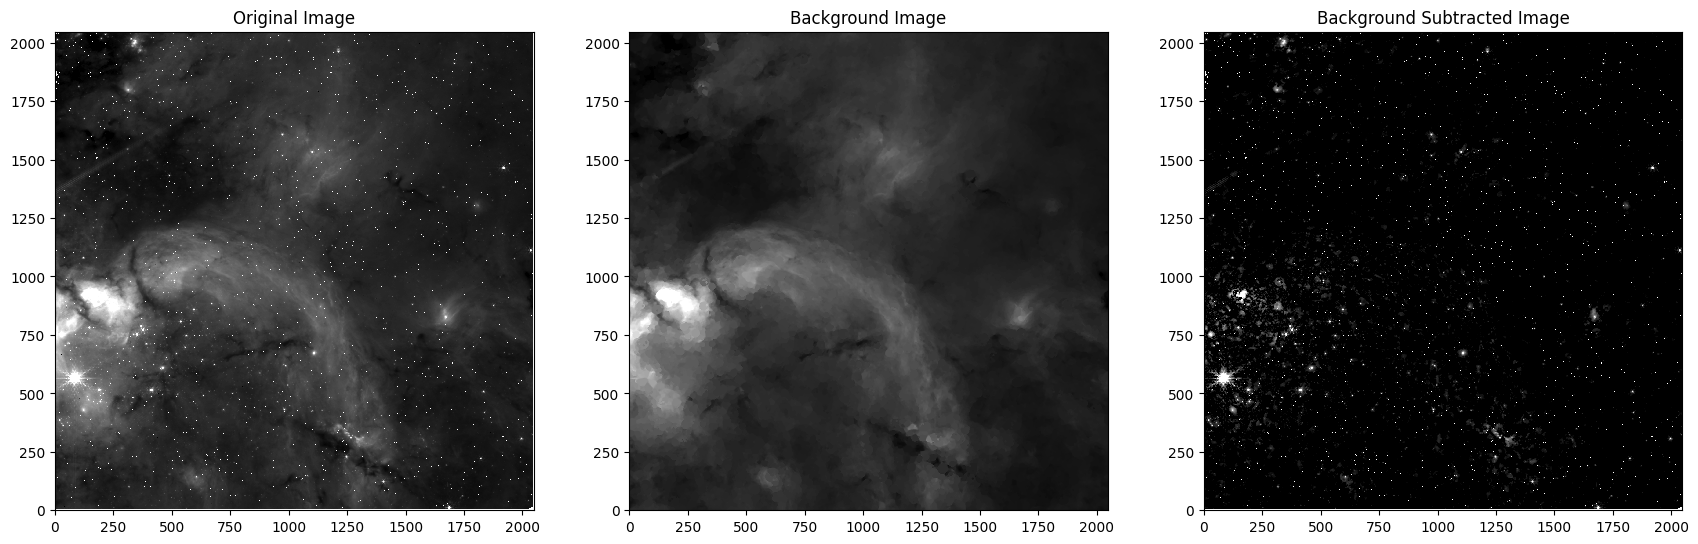

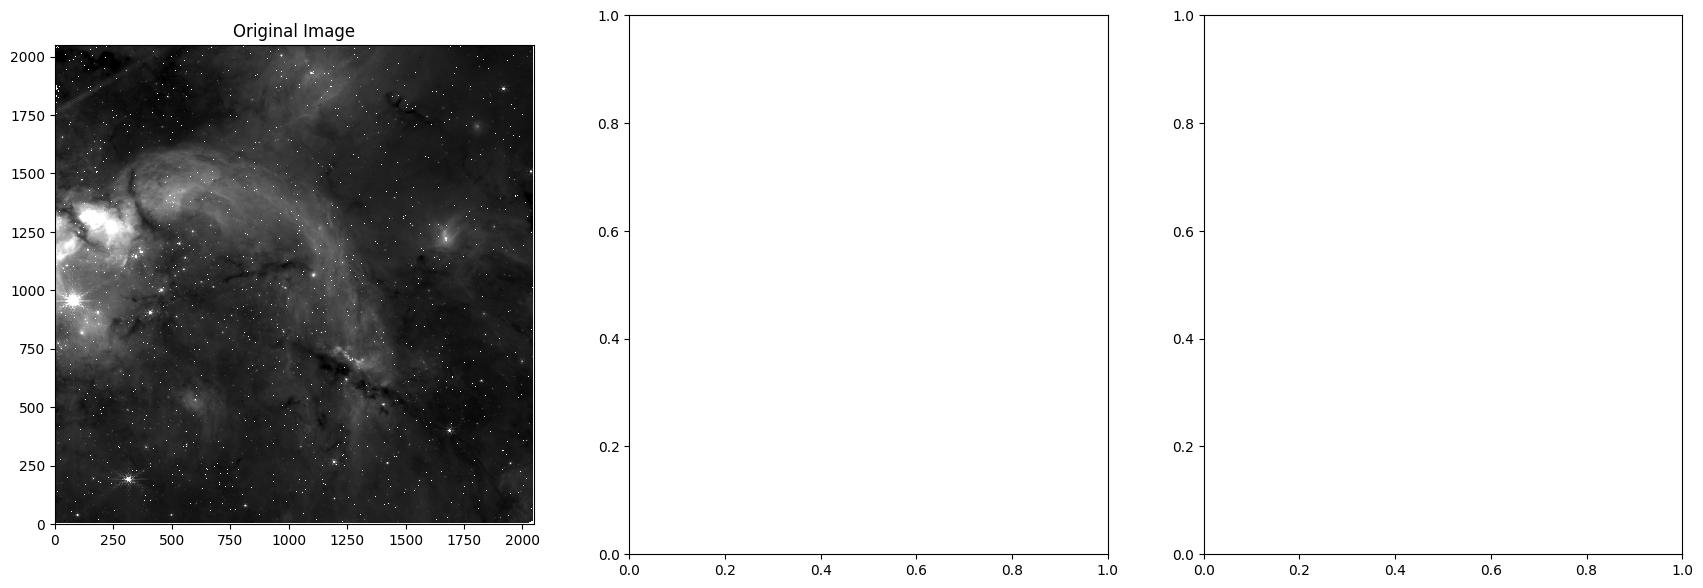

In [10]:
import glob
import time
import numpy
import crowdsource
import regions
import numpy as np
from functools import cache
from astropy.convolution import convolve, Gaussian2DKernel
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy.visualization import simple_norm
from astropy.modeling.fitting import LevMarLSQFitter
from astropy import wcs
from astropy import table
from astropy import stats
from astropy import units as u
from astropy.nddata import NDData
from astropy.io import fits
from scipy import ndimage
import requests
import requests.exceptions
import urllib3
import urllib3.exceptions
from photutils.detection import DAOStarFinder, IRAFStarFinder
from photutils.psf import IntegratedGaussianPRF, extract_stars, EPSFStars, EPSFModel
try:
    # version >=1.7.0, doesn't work: the PSF is broken (https://github.com/astropy/photutils/issues/1580?)
    from photutils.psf import PSFPhotometry, IterativePSFPhotometry, SourceGrouper
except:
    # version 1.6.0, which works
    from photutils.psf import BasicPSFPhotometry as PSFPhotometry, IterativelySubtractedPSFPhotometry as IterativePSFPhotometry, DAOGroup as SourceGrouper
try:
    from photutils.background import MMMBackground, MADStdBackgroundRMS, MedianBackground, Background2D, LocalBackground
except:
    from photutils.background import MMMBackground, MADStdBackgroundRMS, MedianBackground, Background2D
    from photutils.background import MMMBackground as LocalBackground

from photutils.psf import EPSFBuilder
from photutils.psf import extract_stars

import warnings
from astropy.utils.exceptions import AstropyWarning, AstropyDeprecationWarning
warnings.simplefilter('ignore', category=AstropyWarning)
warnings.simplefilter('ignore', category=AstropyDeprecationWarning)

from crowdsource import crowdsource_base
from crowdsource.crowdsource_base import fit_im, psfmod

from astroquery.svo_fps import SvoFps
from astropy.table import Table, vstack

import pylab as pl
pl.rcParams['figure.facecolor'] = 'w'
pl.rcParams['image.origin'] = 'lower'

import matplotlib.pyplot as plt
from astropy.wcs import WCS

print("Done with imports", flush=True)
# step i )  load the catalog and do the quality assessment
# for the quality assessment, some tests are required to see the effect of masking
# load the catalog obtained from each exposure file

nvisits = {'2221': {'brick': 1, 'cloudc': 2},
               '1182': {'brick': 2},
               '6151': {'w51': 1  }
               }
def update_param(filepath, param_name, new_value):
    lines = []
    with open(filepath, "r") as f:
        for line in f:
            if line.strip().startswith(param_name + " "):  # match beginning of line
                parts = line.split("=")
                if len(parts) >= 2:
                    # keep comments if exist
                    comment = "//" + parts[1].split("//")[1] if "//" in parts[1] else ""
                    line = f"{param_name} = {new_value} {comment}\n"
            lines.append(line)

    with open(filepath, "w") as f:
        f.writelines(lines)
    print(f"Updated {param_name} to {new_value}")

def get_filenames(basepath, filtername, proposal_id, field, each_suffix, module, pupil='clear', visitid='001'):

    # jw01182004002_02101_00012_nrcalong_destreak_o004_crf.fits
    # jw02221001001_07101_00012_nrcalong_destreak_o001_crf.fits
    # jw02221001001_05101_00022_nrcb3_destreak_o001_crf.fits
    glstr = f'{basepath}/{filtername}/pipeline/jw0{proposal_id}{field}{visitid}*{module}*_{each_suffix}.fits'
    
  
    fglob = glob.glob(glstr)
    for st in fglob:
        
        if 'align' in st or 'uncal' in st:
            print(f"Removing {st} from glob string because it is an alignment file")
            fglob.remove(st)
    if len(fglob) == 0:
        raise ValueError(f"No matches found to {glstr}")
    else:
        return fglob
modules = ['nrca', 'nrcb']
filternames = ['F480M']
proposal_id = '6151'
target = 'w51'
index = -1

field_to_reg_mapping = {'2221': {'001': 'brick', '002': 'cloudc'},
                            '1182': {'004': 'brick'},
                            '6151': {'001': 'w51'}}[proposal_id]
reg_to_field_mapping = {v:k for k,v in field_to_reg_mapping.items()}
field = reg_to_field_mapping[target]

basepath = f'/orange/adamginsburg/jwst/{field_to_reg_mapping[field]}'




if True:
    for module in modules:
        detector = module # no sub-detectors for long-NIRCAM
        for filtername in filternames:
            if True:
                for visitid in range(1, nvisits[proposal_id][target] + 1):
                    visitid = f'{visitid:03d}'
                    
                    filenames = get_filenames(basepath, filtername, proposal_id,
                                              field, visitid=visitid,
                                              each_suffix='cal',
                                              module=module, pupil='clear')
                    for i, filename in enumerate(filenames):
                        if i<=3:
                            exposurenumber = int(filename.split("_")[2])
                            exposure_id = filename.split("_")[2]
                            visit_id = filename.split("_")[0][-3:]
                            vgroup_id = filename.split("_")[1]
                            exposure_ = f'_exp{exposurenumber:05d}'
                            visitid_ = f'_visit{int(visitid):03d}' if visitid is not None else ''
                            vgroupid_ = f'_vgroup{int(vgroup_id)}' if vgroup_id is not None else ''

                            fig = plt.figure(figsize=(21,7))
                            ax1 = fig.add_subplot(1,3,1)
                            ax2 = fig.add_subplot(1,3,2)
                            ax3 = fig.add_subplot(1,3,3)
                            #original image, model image, residual image
                            img = fits.getdata(filename, ext=('SCI', 1))
                            norm = simple_norm(img, 'sqrt', percent=99.5)
                            ap_file = filename.replace('.fits', '_starbug2-ap.fits')
                            catalog = Table.read(ap_file)
                            print(catalog.columns)
                            ax1.imshow(img, origin='lower', cmap='gray', norm=norm, interpolation='nearest')
                            ax1.set_title('Original Image')
                            #ax1.scatter(catalog['xcentroid'], catalog['ycentroid'], s=10, edgecolor='cyan', facecolor='none')

                            bkg_img_filename = filename.replace('.fits', '_starbug2-bgd.fits')
                            bkg_img = fits.getdata(bkg_img_filename)
                            img_bkgsub = img - bkg_img
                            ax2.imshow(bkg_img, origin='lower', cmap='gray', norm=norm, interpolation='nearest')
                            ax2.set_title('Background Image')   

                            ax3.imshow(img_bkgsub, origin='lower', cmap='gray', norm=norm, interpolation='nearest')
                            ax3.set_title('Background Subtracted Image')

# step iii) using the same coordinates of the orignal catalog, do PSF photometry on the background subtracted images


